In [ ]:
# Question 1: Numeric variable: For ./data/airbnb_hw.csv, clean the Price variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
# Answer: 
#       I started with defining the variable I am woring with. I made sure that any missing variables would be properly recognized.I replaced the dollar signs and commas because that woud skew results in terms of when the number increases above 999, then there will start to be commas within the number. Therefore you need to remove this in order to get proper results. After cleaning the variable, I saw a result of 0 missing variables. 
# See below for code for Question 1. 

df.shape:
(30478, 13) 

df.dtypes:
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object 

df.columns:
Index(['Host Id', 'Host Since', 'Name', 'Neighbourhood ', 'Property Type',
       'Review Scores Rating (bin)', 'Room Type', 'Zipcode', 'Beds',
       'Number of Records', 'Number Of Reviews', 'Price',
       'Review Scores Rating'],
      dtype='object') 

before coercion: 
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 

after coercion: 
 count    30478.000000
mean       163.589737
std        

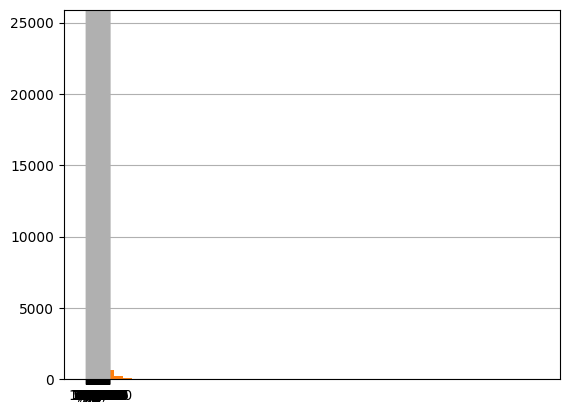

In [4]:
import numpy as np # Import the numpy package into your workspace
import matplotlib.pyplot as plt # Import matplotlib into your workspace
import pandas as pd  # Import the pandas package into your workspace

df = pd.read_csv('./data/airbnb_hw.csv',low_memory=False)

print("df.shape:")
print(df.shape, '\n')

print("df.dtypes:")
print(df.dtypes, '\n')

print("df.columns:")
print(df.columns, '\n')

df.head()

var = 'Price' # clean the price variable
print('before coercion: \n', df[var].describe(),'\n')
df[var].hist(bins=50)

df[var] = df[var].replace(' ', np.nan)
df[var] =df['Price'].astype(str).str.replace(',', '').str.replace('$','')
df[var] = pd.to_numeric(df[var], errors='coerce')
df['price_nan'] = df[var].isnull() # Equals 1 if missing, 0 if non-null

print('after coercion: \n', df[var].describe(),'\n') # Describe the numeric variable
df[var].hist(bins=50) # Histogram of the variable values
print('Missing Variables: \n', sum(df['price_nan']),'\n') # How many missing values are there?

In [ ]:
# Question 2***: Categorical variable: For the Minnesota police use of for data, ./data/mn_police_use_of_force.csv, clean the subject_injury variable, handling the NA's; this gives a value Yes when a person was injured by police, and No when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned subject_injury variable with the force_type variable. Are there any patterns regarding when the data are missing?
# Answer: 
#       The proportion of values missing is 9848/12925 which is about 76.19%. Yes, this is a big concern because the majority of the data is missing which is not then accurate and representative of fair research because so much data is ommitted. The pattern I see when I cross tabulate is that the ommitted data is usually regarding data that has to do with force or bodily harm.      
# See below for Question 2 code

In [3]:
import numpy as np # Import the numpy package into your workspace
import matplotlib.pyplot as plt # Import matplotlib into your workspace
import pandas as pd  # Import the pandas package into your workspace

df = pd.read_csv('./data/mn_police_use_of_force.csv',low_memory=False)

print("df.shape:")
print(df.shape, '\n') 

print("df.dtypes:")
print(df.dtypes, '\n')

print("df.columns:")
print(df.columns, '\n')

df.head()

var = 'subject_injury'
print(df['subject_injury'].unique(), '\n') # A Categorical Example
df['subject_injury'] = df['subject_injury'].replace(' ',np.nan) 
print(df['subject_injury'].value_counts(), '\n')

print(df['subject_injury'].isnull().sum(), '\n') # Total number of missing values
print(len(df), '\n') # Total number of observations
print(df['subject_injury'].isnull().sum() / len(df), '\n') # Proportion of missing values

ct = pd.crosstab(df['subject_injury'], df['force_type'])
print(ct, '\n')


df.shape:
(12925, 13) 

df.dtypes:
response_datetime     object
problem               object
is_911_call           object
primary_offense       object
subject_injury        object
force_type            object
force_type_action     object
race                  object
sex                   object
age                  float64
type_resistance       object
precinct               int64
neighborhood          object
dtype: object 

df.columns:
Index(['response_datetime', 'problem', 'is_911_call', 'primary_offense',
       'subject_injury', 'force_type', 'force_type_action', 'race', 'sex',
       'age', 'type_resistance', 'precinct', 'neighborhood'],
      dtype='object') 

[nan 'No' 'Yes'] 

subject_injury
Yes    1631
No     1446
Name: count, dtype: int64 

9848 

12925 

0.7619342359767892 

force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
No                  0          1093                131        2   
Yes

In [ ]:
# See below for Question 3 code

In [4]:
import numpy as np # Import the numpy package into your workspace
import matplotlib.pyplot as plt # Import matplotlib into your workspace
import pandas as pd  # Import the pandas package into your workspace

url = 'http://www.vcsc.virginia.gov/pretrialdataproject/October%202017%20Cohort_Virginia%20Pretrial%20Data%20Project_Deidentified%20FINAL%20Update_10272021.csv'
df = pd.read_csv(url, low_memory=False)
df.shape

print("df.shape:")
print(df.shape, '\n') 

print("df.dtypes:")
print(df.dtypes, '\n')

print("df.columns:")
print(df.columns, '\n')

df.head()

var = 'WhetherDefendantWasReleasedPretrial' # A Dummy Example
print(df['WhetherDefendantWasReleasedPretrial'].unique(), '\n')
df[var] = df['WhetherDefendantWasReleasedPretrial'].replace([9,99], np.nan) # Notice the list
print(df['WhetherDefendantWasReleasedPretrial'].value_counts(),'\n') 

df.shape:
(22986, 709) 

df.dtypes:
InternalStudyID                                                 object
REQ_REC#                                                        object
Defendant_Sex                                                   object
Defendant_Race                                                  object
Defendant_BirthYear                                             object
                                                                 ...  
NewFelonySexualAssaultArrest_Disposition                        object
Intertnalindicator_ReasonforExcludingFromFollowUpAnalysis        int64
CriminalHistoryRecordsReturnedorCMSRecordsFoundforIndividual    object
DispRecordFoundforChargesinOct2017Contact_Atleast1dispfound      int64
CrimeCommission2021ReportClassificationofDefendants             object
Length: 709, dtype: object 

df.columns:
Index(['InternalStudyID', 'REQ_REC#', 'Defendant_Sex', 'Defendant_Race',
       'Defendant_BirthYear', 'Defendant_Age', 'Defendant_AgeGroup',


In [ ]:
# Question 4
# Answer: First, I wrote in to recognize that "" would show up as true missing values. Then I coerced the variable to a numeric. Next, i created a missing dummy variable. Then, I cross-tabulated with Sentence type. In the end, I asked it to count the amount of missing variables. 
#       See below for code for Question 4

In [11]:
import numpy as np # Import the numpy package into your workspace
import matplotlib.pyplot as plt # Import matplotlib into your workspace
import pandas as pd  # Import the pandas package into your workspace

url = 'http://www.vcsc.virginia.gov/pretrialdataproject/October%202017%20Cohort_Virginia%20Pretrial%20Data%20Project_Deidentified%20FINAL%20Update_10272021.csv'
df = pd.read_csv(url, low_memory=False)
df.shape

print("df.shape:")
print(df.shape, '\n') 

print("df.dtypes:")
print(df.dtypes, '\n')

print("df.columns:")
print(df.columns, '\n')

df.head()

var = 'ImposedSentenceAllChargeInContactEvent'
df[var] = df[var].replace( " ", np.nan)
df[var] = pd.to_numeric(df[var], errors='coerce')

df['ImposedSentenceAllChargeInContactEvent_na'] = df[var].isnull()
print(pd.crosstab(df['ImposedSentenceAllChargeInContactEvent_na'], df['SentenceTypeAllChargesAtConvictionInContactEvent']), '\n')
print(df[var].describe(), '\n')
print('Total Missings:', sum(df['ImposedSentenceAllChargeInContactEvent_na']), '\n')


df.shape:
(22986, 709) 

df.dtypes:
InternalStudyID                                                 object
REQ_REC#                                                        object
Defendant_Sex                                                   object
Defendant_Race                                                  object
Defendant_BirthYear                                             object
                                                                 ...  
NewFelonySexualAssaultArrest_Disposition                        object
Intertnalindicator_ReasonforExcludingFromFollowUpAnalysis        int64
CriminalHistoryRecordsReturnedorCMSRecordsFoundforIndividual    object
DispRecordFoundforChargesinOct2017Contact_Atleast1dispfound      int64
CrimeCommission2021ReportClassificationofDefendants             object
Length: 709, dtype: object 

df.columns:
Index(['InternalStudyID', 'REQ_REC#', 'Defendant_Sex', 'Defendant_Race',
       'Defendant_BirthYear', 'Defendant_Age', 'Defendant_AgeGroup',


In [ ]:
#Q2

#3. The range of attacks have increased since 2000 but has fluctuated. The range varies from as 1900-2026. 
#5. The proportion of males is 76.68%. 
#6. The proportion of unprovoked is 74.41%. 
#8. More likely to have unprovoked attacks on men. It is less likely to be fatal when it is provoked. More likely to be fatal towards men than women but not by much. I don't know how to swim very well so I would definitely not be okay next to shark. 
#9. The proportion is about 12.87% by white sharks.  

# See below for code for Q2. 

In [13]:
import numpy as np # Import the numpy package into your workspace
import matplotlib.pyplot as plt # Import matplotlib into your workspace
import pandas as pd  # Import the pandas package into your workspace

url = 'https://sharkattackfile.net/spreadsheets/GSAF5.xls'
df = pd.read_excel(url)

print("df.shape:")
print(df.shape, '\n') 

print("df.dtypes:")
print(df.dtypes, '\n')

print("df.columns:")
print(df.columns, '\n')

df = df.dropna(axis=1, how='all')
print(df.shape, '\n')



df.shape:
(7042, 23) 

df.dtypes:
Date               object
Year              float64
Type               object
Country            object
State              object
Location           object
Activity           object
Name               object
Sex                object
Age                object
Injury             object
Fatal Y/N          object
Time               object
Species            object
Source             object
pdf                object
href formula       object
href               object
Case Number        object
Case Number.1      object
original order    float64
Unnamed: 21        object
Unnamed: 22        object
dtype: object 

df.columns:
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object') 

(7042, 23) 



count    7040.000000
mean     1935.621449
std       271.221061
min         0.000000
25%      1948.000000
50%      1986.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64 



<Axes: >

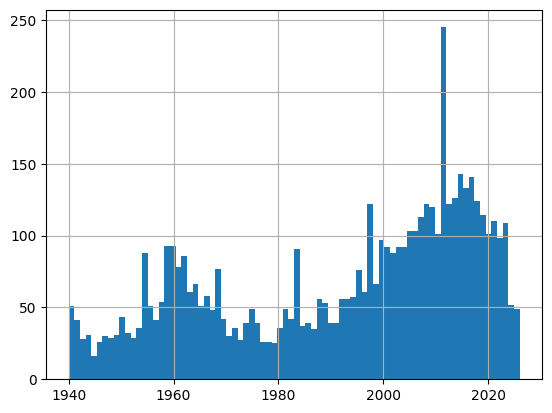

In [14]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')  
print(df['Year'].describe(), '\n')

df = df[df['Year'] >= 1940]  # Filter
df['Year'].hist(bins=80)

<Axes: >

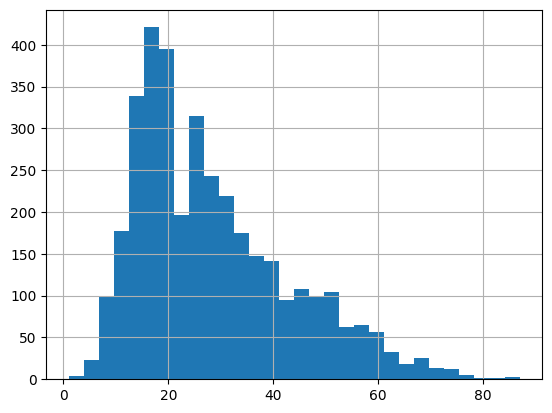

In [15]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'].hist(bins=30)

In [16]:
var = 'Sex'
df[var] = df[var].str.strip().str.upper()
print(df[var].value_counts(), '\n')
print((df[var] == 'M').mean(), '\n')

Sex
M        4333
F         720
LLI         1
M X 2       1
Name: count, dtype: int64 

0.7868167786453605 



In [22]:
df['Type'] = df['Type'].str.strip().str.capitalize()
df['Type'] = df['Type'].where(df['Type'].isin(['Unprovoked', 'Provoked']), 'Unknown')
print(df['Type'].value_counts(normalize=True), '\n')  # Proportion unprovoked


Type
Unprovoked    0.744144
Unknown       0.161431
Provoked      0.094425
Name: proportion, dtype: float64 



In [ ]:
df['Fatal Y/N'] = df['Fatal Y/N'].str.strip().str.upper()
df['Fatal Y/N'] = df['Fatal Y/N'].where(df['Fatal Y/N'].isin(['Y', 'N']), 'Unknown')
print(df['Fatal Y/N'].value_counts(normalize=True), '\n')

print(pd.crosstab(df['Sex'], df['Type'], normalize='columns'), '\n')
# It attacks men more unprovoked

print(pd.crosstab(df['Type'], df['Fatal Y/N'], normalize='index'), '\n')
#It is more fatal when it is unprovoked

print(pd.crosstab(df['Sex'], df['Fatal Y/N'], normalize='index'), '\n')
#More fatal for men than women 



Fatal Y/N
N          0.766479
Y          0.149628
Unknown    0.083893
Name: proportion, dtype: float64 

Type   Provoked   Unknown  Unprovoked
Sex                                  
F      0.058824  0.127010    0.154915
LLI    0.000000  0.000000    0.000253
M      0.941176  0.871383    0.844832
M X 2  0.000000  0.001608    0.000000 

Fatal Y/N          N   Unknown         Y
Type                                    
Provoked    0.957692  0.017308  0.025000
Unknown     0.411699  0.449944  0.138358
Unprovoked  0.819180  0.012933  0.167887 

Fatal Y/N         N   Unknown         Y
Sex                                    
F          0.794444  0.081944  0.123611
LLI        1.000000  0.000000  0.000000
M          0.773367  0.074544  0.152089
M X 2      0.000000  1.000000  0.000000 



In [40]:
var = 'Species '
df[var] = df[var].astype(str).str.lower()

df['white_shark'] = df[var].str.contains('white', na=False)
print(df['white_shark'].mean(), '\n')  # Proportion


0.12874523333938623 

